# 03 — NLP Analysis: Description & Amenities
**Egypt Real Estate 2026**

This notebook applies NLP techniques to the `description` column and `amenities` field of the cleaned dataset.
Steps covered:
1. Language detection (English vs Arabic split)
2. English NLP pipeline (cleaning, TF-IDF, WordCloud)
3. Topic modeling via LDA (5 topics)
4. Sentiment analysis (VADER)
5. Export enriched dataset: `egypt_re_nlp.csv`

**Input:** `egypt_re_clean.csv`  
**Output:** `egypt_re_nlp.csv`

## 0. Install Dependencies

In [1]:
# # Install all required packages (run once)
# import subprocess, sys

# packages = [
#     "langdetect",
#     "nltk",
#     "textblob",
#     "vaderSentiment",
#     "wordcloud",
#     "scikit-learn",
#     "matplotlib",
#     "seaborn",
#     "pandas",
#     "numpy",
# ]
# for pkg in packages:
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# print("All packages installed.")

## 1. Imports & NLTK Downloads

In [2]:
import warnings
warnings.filterwarnings("ignore")

import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from langdetect import detect, LangDetectException
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Download NLTK data
for resource in ["stopwords", "punkt", "wordnet", "omw-1.4","punkt_tab", "averaged_perceptron_tagger"]:
    nltk.download(resource, quiet=True)

# Style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Output directory for figures
import os
os.makedirs(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\nlp_outputs", exist_ok=True)

print("Imports complete.")

Imports complete.


## 2. Load Dataset

In [3]:
df = pd.read_csv(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_clean.csv", low_memory=False)

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nDescription column null count: {df['description'].isna().sum()} / {len(df)}")
df[["listing_id", "offering_type", "city", "description", "price_per_sqm"]].head(3)

Shape: (35830, 70)
Columns: ['listing_id', 'category', 'property_type', 'offering_type', 'completion_status', 'price_egp', 'price_period', 'price_currency', 'location_full', 'city', 'town', 'district', 'subdistrict', 'lat', 'lon', 'bedrooms', 'bathrooms', 'area_value', 'area_unit', 'furnished', 'listing_level', 'is_premium', 'is_verified', 'is_featured', 'is_new_construction', 'is_direct_from_dev', 'is_exclusive', 'listed_date', 'images_count', 'has_view_360', 'description', 'amenities', 'payment_method', 'agent_id', 'agent_name', 'agent_is_super', 'broker_name', 'scraped_at', 'listed_date_original', 'year', 'month', 'week', 'day_of_week', 'days_since_listed', 'listing_age_days', 'area_flag', 'amen_balcony', 'amen_security', 'amen_covered_parking', 'amen_view_of_landmark', 'amen_shared_gym', 'amen_lobby_in_building', 'amen_central_a_c', 'amen_kitchen_appliances', 'amen_built_in_wardrobes', 'amen_shared_spa', 'amen_shared_pool', 'amen_walk_in_closet', 'amen_study', 'amen_children_s_pool

,listing_id,offering_type,city,description,price_per_sqm
0,HYEPN5XPWQT7K05K4ST7EDWW5R,Rent,Cairo,Unit Description: Location: Villette Compound ...,520.833333
1,9Q295E8B6ET3V30Z31925BR6ZG,Rent,Giza,For Rent – Premium 196m² Fully Finished Apartm...,255.102041
2,R9PTSC3V5RZ77ZT9X69TBE1PEC,Rent,Giza,Furnished villa for rent at a special price To...,375.000000


## 3. Language Detection

We detect the language of each description row using `langdetect`.
- Rows where detection fails (too short, numeric-only, NaN) are labeled `"unknown"`.
- We split the dataset into `df_en` (English) and `df_ar` (Arabic) for downstream NLP.

In [4]:
def detect_lang(text):
    """Return ISO language code or 'unknown' on failure."""
    if not isinstance(text, str) or len(text.strip()) < 20:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

print("Detecting languages — this may take a minute on large datasets...")
df["lang"] = df["description"].apply(detect_lang)

lang_counts = df["lang"].value_counts()
print("\nLanguage distribution:")
print(lang_counts.head(10))

Detecting languages — this may take a minute on large datasets...

Language distribution:
lang
en         34325
ar          1494
fr             2
unknown        2
nl             2
cy             1
da             1
it             1
sk             1
de             1
Name: count, dtype: int64


English descriptions : 34,325 rows (95.8%)
Arabic descriptions  : 1,494 rows (4.2%)
Other/Unknown        : 11 rows (0.0%)


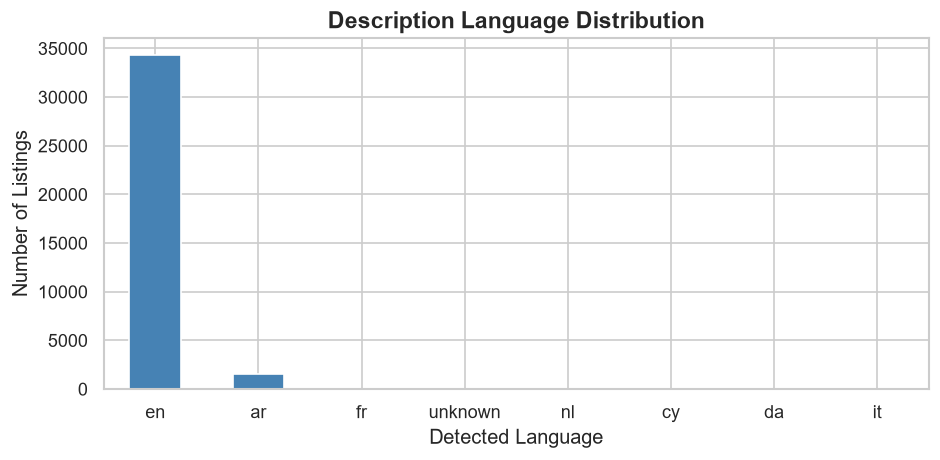

In [6]:
# Split into EN and AR subsets
df_en = df[df["lang"] == "en"].copy()
df_ar = df[df["lang"] == "ar"].copy()
df_other = df[~df["lang"].isin(["en", "ar"])].copy()

print(f"English descriptions : {len(df_en):,} rows ({len(df_en)/len(df)*100:.1f}%)")
print(f"Arabic descriptions  : {len(df_ar):,} rows ({len(df_ar)/len(df)*100:.1f}%)")
print(f"Other/Unknown        : {len(df_other):,} rows ({len(df_other)/len(df)*100:.1f}%)")

# Bar chart of language split
top_langs = lang_counts.head(8)
fig, ax = plt.subplots(figsize=(8, 4))
top_langs.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Description Language Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Detected Language")
ax.set_ylabel("Number of Listings")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\nlp_outputs/01_language_distribution.png")
plt.show()

## 4. English NLP Pipeline

For English descriptions we apply:
1. HTML stripping & whitespace normalization (already done in Phase 1, but re-applied defensively)
2. Lowercase conversion
3. Punctuation and digit removal
4. Stopword removal (English)
5. Lemmatization using WordNetLemmatizer

Short texts (<20 chars after cleaning) are dropped from NLP analysis but retained in the main dataframe.

In [7]:
lemmatizer = WordNetLemmatizer()
EN_STOPWORDS = set(stopwords.words("english"))

# Add domain-specific stop words that add noise
CUSTOM_STOPWORDS = {
    "property", "apartment", "unit", "floor", "building",
    "area", "sqm", "meter", "square", "located", "location",
    "available", "contact", "call", "price", "offer", "egp",
    "cairo", "egypt", "giza", "compound", "new", "one", "two",
    "three", "four", "five", "also", "get", "great", "good"
}
ALL_STOPWORDS = EN_STOPWORDS | CUSTOM_STOPWORDS


def clean_text(text: str) -> str:
    """Full NLP cleaning pipeline for English text."""
    if not isinstance(text, str):
        return ""
    # Strip HTML tags
    text = re.sub(r"<[^>]+>", " ", text)
    # Lowercase
    text = text.lower()
    # Remove digits
    text = re.sub(r"\d+", " ", text)
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in ALL_STOPWORDS and len(tok) > 2
    ]
    return " ".join(tokens)


print("Cleaning English descriptions...")
df_en["description_clean"] = df_en["description"].apply(clean_text)

# Drop rows where cleaned text is too short
df_en_valid = df_en[df_en["description_clean"].str.len() >= 20].copy()
print(f"Valid EN rows after cleaning: {len(df_en_valid):,} / {len(df_en):,}")

# Sample output
df_en_valid[["listing_id", "description_clean"]].head(2)

Cleaning English descriptions...
Valid EN rows after cleaning: 34,325 / 34,325


,listing_id,description_clean
0,HYEPN5XPWQT7K05K4ST7EDWW5R,description villette sodic fifth settlement la...
1,9Q295E8B6ET3V30Z31925BR6ZG,rent premium fully finished park club golf vie...


### 4.1 Word Frequency (Top 30)

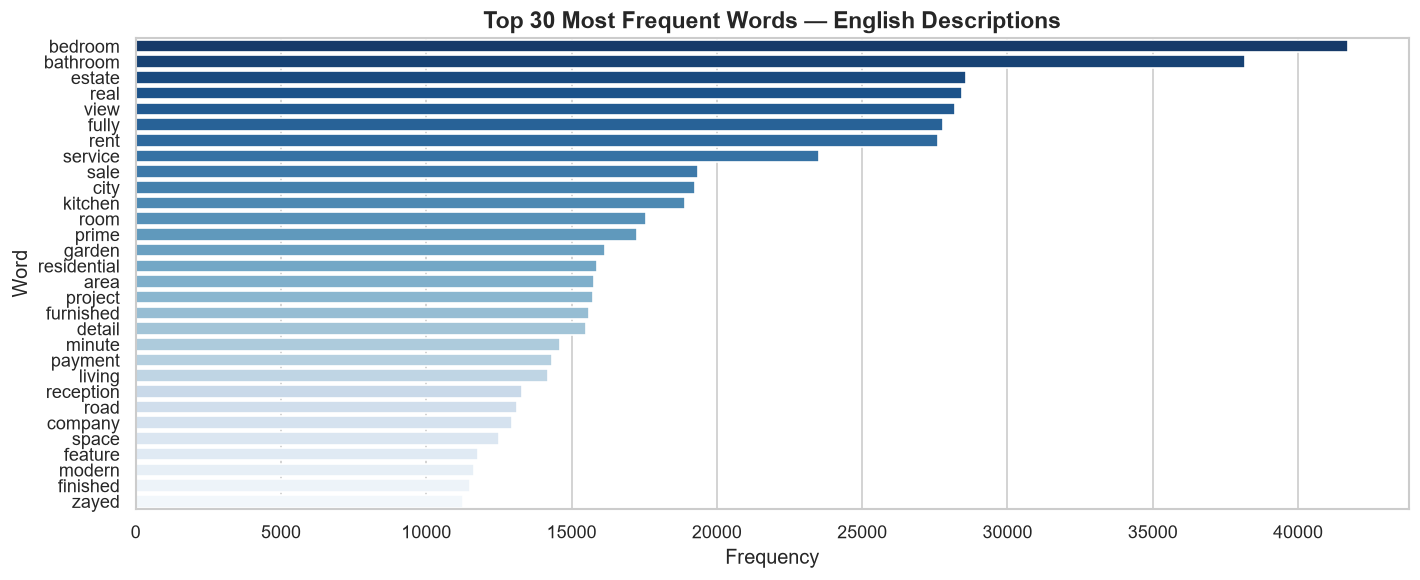

       word  count
    bedroom  41725
   bathroom  38170
     estate  28569
       real  28438
       view  28211
      fully  27793
       rent  27617
    service  23518
       sale  19335
       city  19247
    kitchen  18901
       room  17574
      prime  17239
     garden  16156
residential  15880
       area  15788
    project  15729
  furnished  15586
     detail  15485
     minute  14606
    payment  14317
     living  14174
  reception  13278
       road  13133
    company  12956
      space  12499
    feature  11774
     modern  11648
   finished  11511
      zayed  11279


In [9]:
from collections import Counter

all_words = " ".join(df_en_valid["description_clean"]).split()
word_freq = Counter(all_words)
top30 = pd.DataFrame(word_freq.most_common(30), columns=["word", "count"])

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=top30, x="count", y="word", ax=ax, palette="Blues_r")
ax.set_title("Top 30 Most Frequent Words — English Descriptions", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency")
ax.set_ylabel("Word")
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\nlp_outputs/02_word_frequency_top30.png")
plt.show()

print(top30.to_string(index=False))

### 4.2 TF-IDF Vectorization (Top 500 Features)

In [10]:
tfidf = TfidfVectorizer(
    max_features=500,
    min_df=5,          # word must appear in at least 5 documents
    max_df=0.85,       # ignore words appearing in >85% of docs
    ngram_range=(1, 2) # unigrams + bigrams
)

tfidf_matrix = tfidf.fit_transform(df_en_valid["description_clean"])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_)}")

# Show top features by mean TF-IDF score
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)
top_tfidf = tfidf_df.mean().sort_values(ascending=False).head(20)
print("\nTop 20 features by mean TF-IDF score:")
print(top_tfidf)

TF-IDF matrix shape: (34325, 500)
Vocabulary size: 500

Top 20 features by mean TF-IDF score:
estate              0.051181
real                0.051069
real estate         0.050661
rent                0.049771
view                0.048085
fully               0.047885
room                0.039380
bedroom bathroom    0.037371
city                0.037128
service             0.037029
garden              0.036805
furnished           0.036582
kitchen             0.036555
sale                0.036462
payment             0.035035
prime               0.033741
detail              0.032726
minute              0.032559
project             0.030214
living              0.030041
dtype: float64


### 4.3 WordCloud — Buy vs Rent Listings

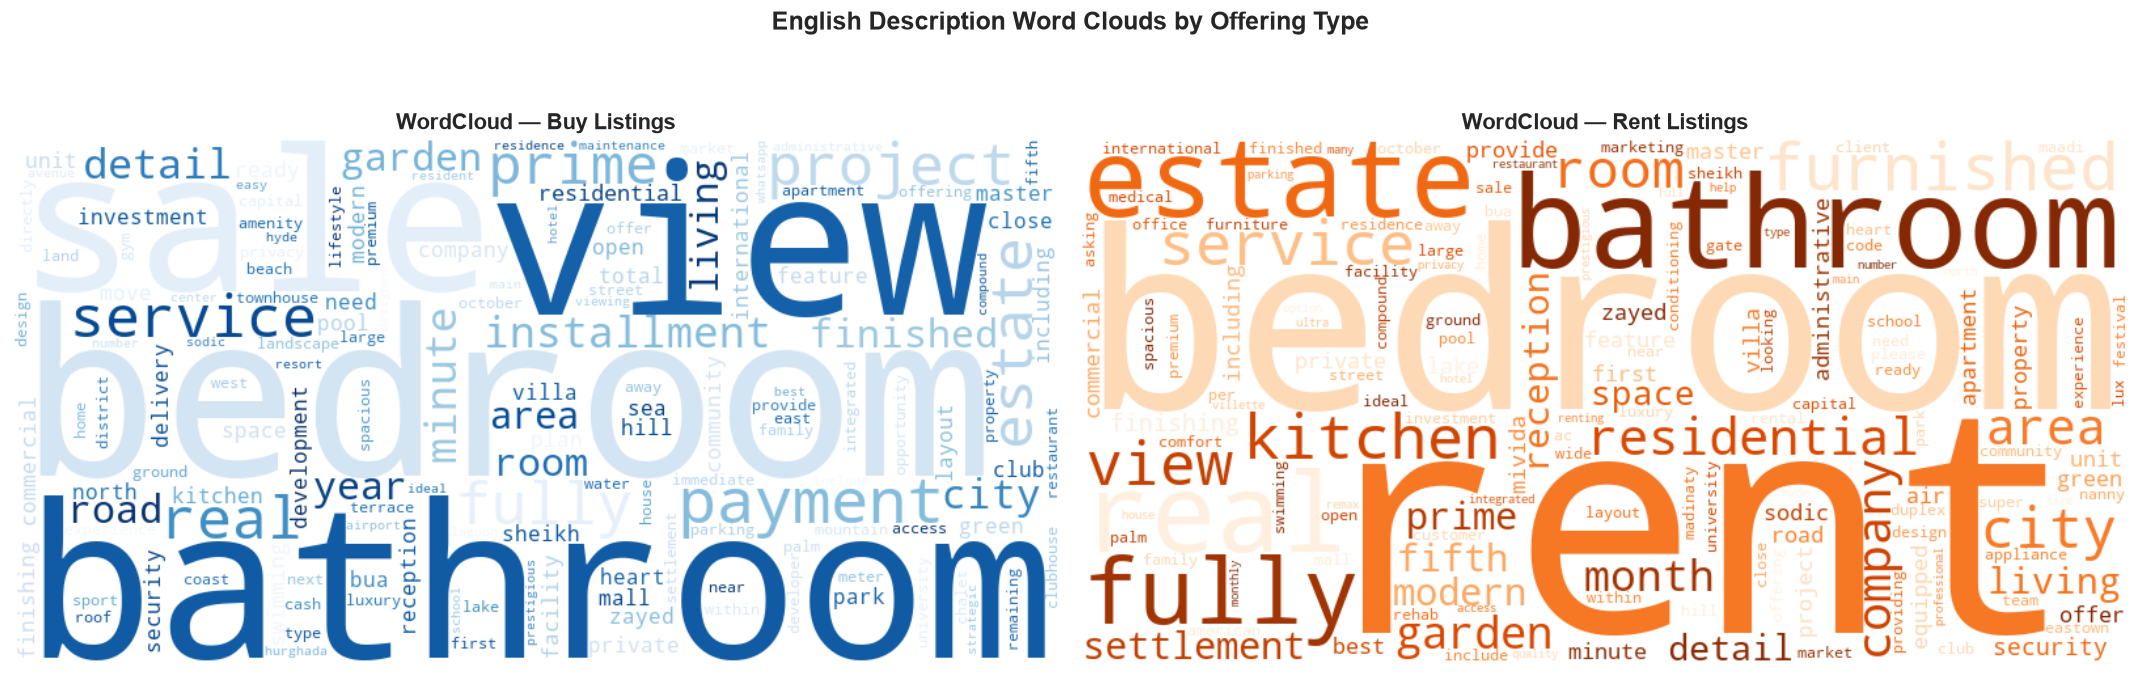

Buy EN listings : 16,567
Rent EN listings: 17,758


In [11]:
def generate_wordcloud(text_series, title, colormap="Blues", ax=None):
    combined = " ".join(text_series.dropna())
    wc = WordCloud(
        width=800, height=400,
        background_color="white",
        colormap=colormap,
        max_words=150,
        collocations=False
    ).generate(combined)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13, fontweight="bold")


fig, axes = plt.subplots(1, 2, figsize=(18, 6))

buy_text = df_en_valid[df_en_valid["offering_type"] == "Buy"]["description_clean"]
rent_text = df_en_valid[df_en_valid["offering_type"] == "Rent"]["description_clean"]

generate_wordcloud(buy_text, "WordCloud — Buy Listings", colormap="Blues", ax=axes[0])
generate_wordcloud(rent_text, "WordCloud — Rent Listings", colormap="Oranges", ax=axes[1])

plt.suptitle("English Description Word Clouds by Offering Type", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\nlp_outputs/03_wordclouds_buy_vs_rent.png", bbox_inches="tight")
plt.show()

print(f"Buy EN listings : {len(buy_text):,}")
print(f"Rent EN listings: {len(rent_text):,}")

## 5. Topic Modeling — LDA (5 Topics)

We use `CountVectorizer` as input to LDA (TF-IDF is not recommended for LDA — raw counts work better).
After fitting, we:
1. Print the top 10 words per topic
2. Manually label each topic
3. Assign `topic_id` and `topic_label` to each row in `df_en_valid`
4. Visualize topic distribution across cities

In [12]:
# Count vectorizer for LDA
count_vec = CountVectorizer(
    max_features=2000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 1)  # LDA works best with unigrams
)
count_matrix = count_vec.fit_transform(df_en_valid["description_clean"])
print(f"Count matrix shape: {count_matrix.shape}")

# Fit LDA
N_TOPICS = 5
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=15,
    learning_method="online",
    learning_offset=50.0,
    random_state=42,
    n_jobs=-1
)
lda.fit(count_matrix)
print("LDA training complete.")

Count matrix shape: (34325, 2000)
LDA training complete.


In [13]:
# Display top words per topic
feature_names = count_vec.get_feature_names_out()
N_TOP_WORDS = 12

topic_top_words = {}
print("=" * 60)
print(f"TOP {N_TOP_WORDS} WORDS PER TOPIC")
print("=" * 60)
for topic_idx, topic in enumerate(lda.components_):
    top_indices = topic.argsort()[: -N_TOP_WORDS - 1 : -1]
    top_words = [feature_names[i] for i in top_indices]
    topic_top_words[topic_idx] = top_words
    print(f"\nTopic {topic_idx}: {', '.join(top_words)}")

TOP 12 WORDS PER TOPIC

Topic 0: estate, real, company, residential, need, marketing, best, sale, commercial, administrative, service, rent

Topic 1: home, living, experience, comfort, modern, investment, service, market, offer, real, estate, space

Topic 2: minute, service, road, project, city, green, view, area, residential, space, mall, feature

Topic 3: zayed, sale, sheikh, hill, october, west, finished, payment, view, fully, sea, palm

Topic 4: rent, fully, view, kitchen, room, detail, garden, reception, prime, furnished, finishing, month


### 5.1 Manual Topic Labels

Review the top words above and assign meaningful labels below.
These defaults are reasonable starting points — **update them** after inspecting your data.

In [14]:
# ✏️  MANUAL LABELS — Update after reviewing top words above
TOPIC_LABELS = {
    0: "Property Sales & Luxury Communities",
    1: "Modern Residential Communities",
    2: "Real Estate Business & Investment",
    3: "Furnished Rental Properties",
    4: "Location, Amenities & Accessibility",
}
print("Topic label mapping:")
for k, v in TOPIC_LABELS.items():
    print(f"  Topic {k}: {v}")
    print(f"    Top words: {', '.join(topic_top_words[k][:8])}")

Topic label mapping:
  Topic 0: Property Sales & Luxury Communities
    Top words: estate, real, company, residential, need, marketing, best, sale
  Topic 1: Modern Residential Communities
    Top words: home, living, experience, comfort, modern, investment, service, market
  Topic 2: Real Estate Business & Investment
    Top words: minute, service, road, project, city, green, view, area
  Topic 3: Furnished Rental Properties
    Top words: zayed, sale, sheikh, hill, october, west, finished, payment
  Topic 4: Location, Amenities & Accessibility
    Top words: rent, fully, view, kitchen, room, detail, garden, reception


In [15]:
# Assign topic to each English listing
doc_topic_matrix = lda.transform(count_matrix)  # shape: (n_docs, n_topics)
df_en_valid["topic_id"] = doc_topic_matrix.argmax(axis=1)
df_en_valid["topic_label"] = df_en_valid["topic_id"].map(TOPIC_LABELS)
df_en_valid["topic_confidence"] = doc_topic_matrix.max(axis=1)

print("Topic distribution:")
print(df_en_valid["topic_label"].value_counts())

Topic distribution:
topic_label
Location, Amenities & Accessibility    11751
Real Estate Business & Investment      10721
Property Sales & Luxury Communities     4232
Modern Residential Communities          3888
Furnished Rental Properties             3733
Name: count, dtype: int64


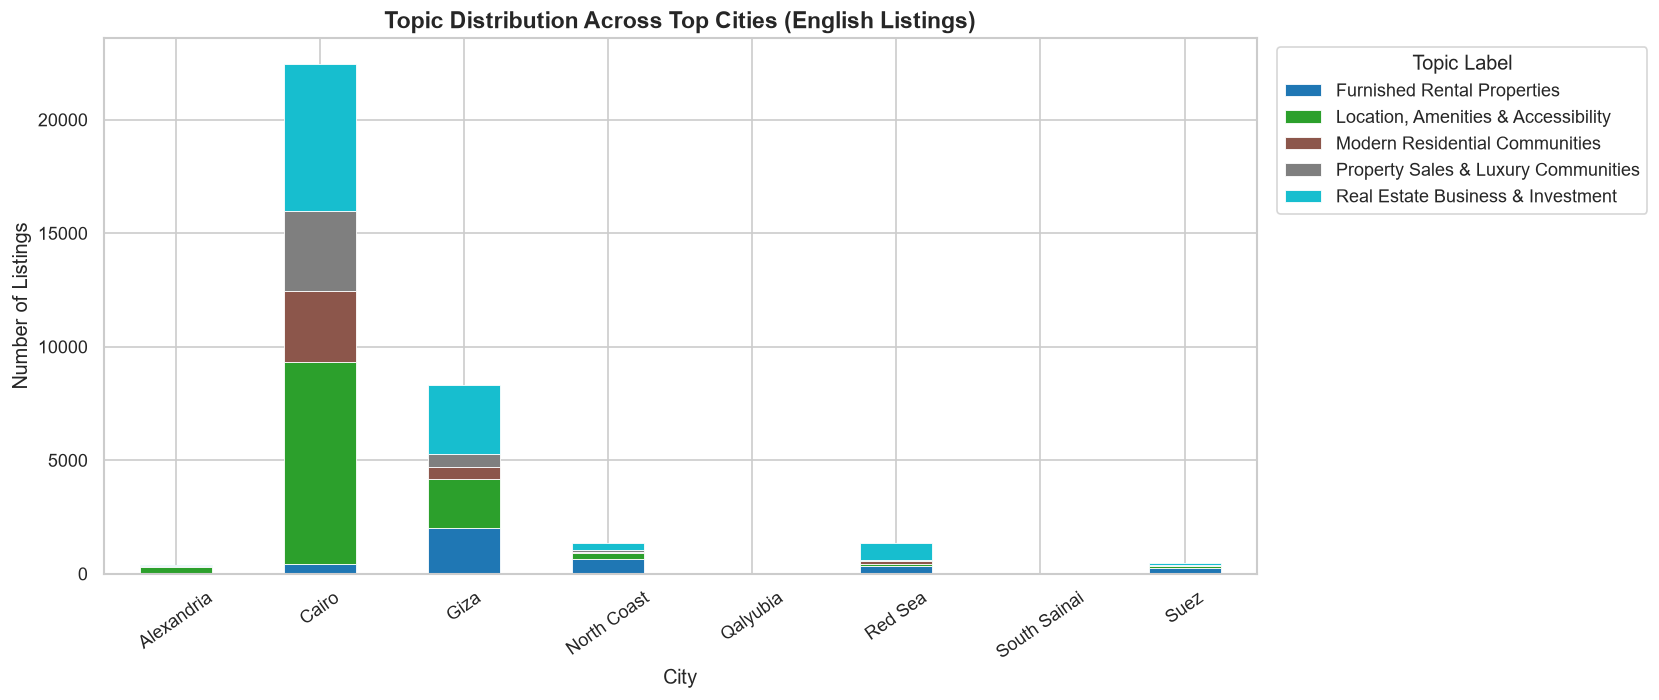

In [16]:
# Visualize topic distribution by city
topic_city = (
    df_en_valid.groupby(["city", "topic_label"])
    .size()
    .reset_index(name="count")
)

top_cities = df_en_valid["city"].value_counts().head(8).index.tolist()
topic_city_top = topic_city[topic_city["city"].isin(top_cities)]

pivot = topic_city_top.pivot(index="city", columns="topic_label", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", edgecolor="white", linewidth=0.5)
ax.set_title("Topic Distribution Across Top Cities (English Listings)", fontsize=14, fontweight="bold")
ax.set_xlabel("City")
ax.set_ylabel("Number of Listings")
ax.legend(title="Topic Label", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\nlp_outputs\04_topic_distribution_by_city.png", bbox_inches="tight")
plt.show()

## 6. Sentiment Analysis — VADER

We use VADER (Valence Aware Dictionary and sEntiment Reasoner) which is well-suited for short, informal texts.
- `sentiment_score`: compound score from VADER (-1 to +1)
- `sentiment_label`: `Positive` (score > 0.05), `Negative` (score < -0.05), else `Neutral`

**Note:** We run VADER on the **original** (non-lemmatized) English description to preserve capitalization and punctuation cues that VADER uses.

In [17]:
vader = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return 0.0
    return vader.polarity_scores(text)["compound"]

def label_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    return "Neutral"

print("Running VADER sentiment analysis...")
df_en_valid["sentiment_score"] = df_en_valid["description"].apply(get_sentiment)
df_en_valid["sentiment_label"] = df_en_valid["sentiment_score"].apply(label_sentiment)

print("\nSentiment label distribution:")
print(df_en_valid["sentiment_label"].value_counts())
print(f"\nMean compound score: {df_en_valid['sentiment_score'].mean():.4f}")

Running VADER sentiment analysis...

Sentiment label distribution:
sentiment_label
Positive    31248
Neutral      2629
Negative      448
Name: count, dtype: int64

Mean compound score: 0.7424


### 6.1 Do Higher-Priced Listings Have More Positive Descriptions?

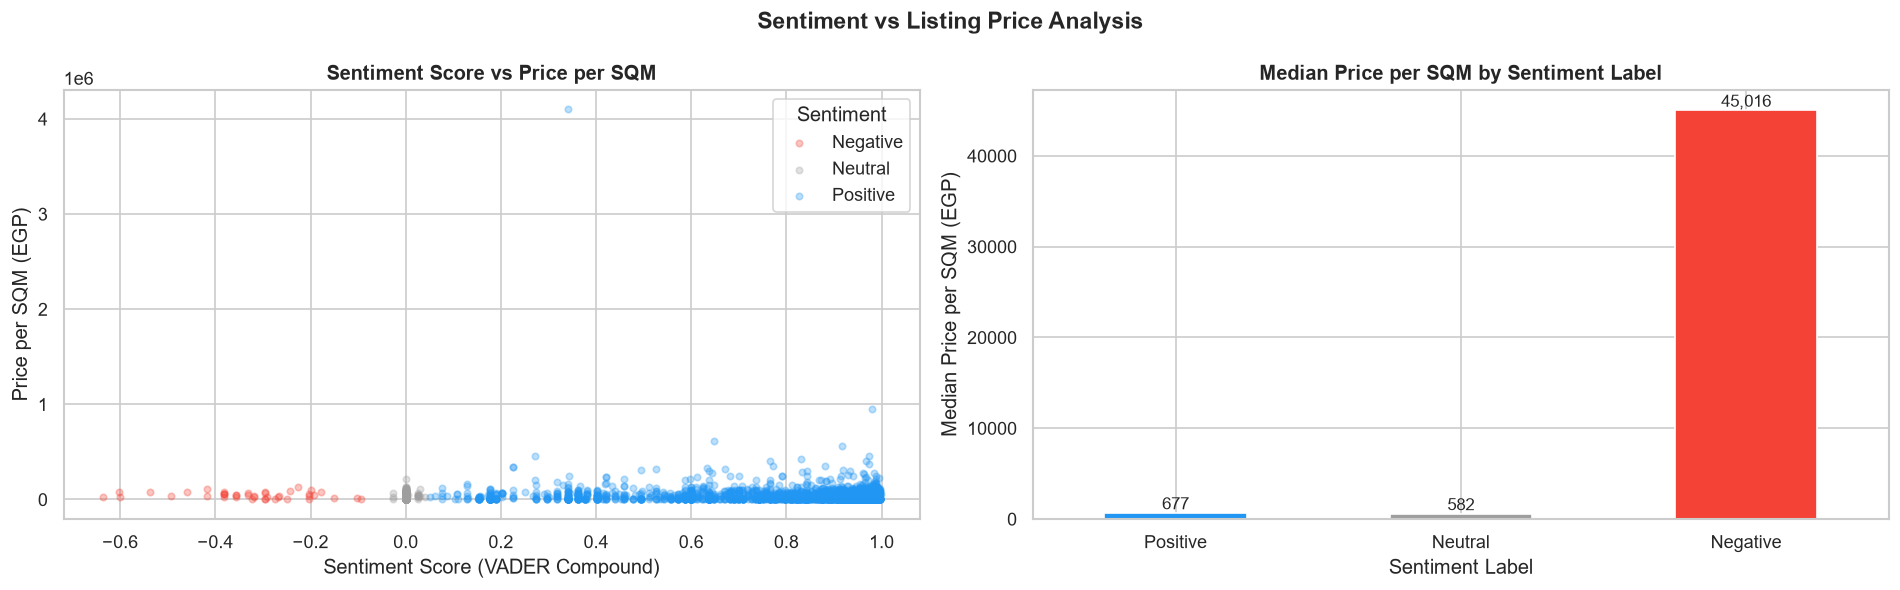


Pearson correlation (sentiment_score vs price_per_sqm): -0.0213


In [19]:
# Scatter: sentiment_score vs price_per_sqm
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter plot
ax = axes[0]
sample = df_en_valid.dropna(subset=["price_per_sqm", "sentiment_score"]).sample(
    min(3000, len(df_en_valid)), random_state=42
)
color_map = {"Positive": "#2196F3", "Neutral": "#9E9E9E", "Negative": "#F44336"}
for label, group in sample.groupby("sentiment_label"):
    ax.scatter(
        group["sentiment_score"],
        group["price_per_sqm"],
        alpha=0.3, s=15,
        color=color_map[label], label=label
    )
ax.set_xlabel("Sentiment Score (VADER Compound)")
ax.set_ylabel("Price per SQM (EGP)")
ax.set_title("Sentiment Score vs Price per SQM", fontweight="bold")
ax.legend(title="Sentiment")

# Median price by sentiment label
ax2 = axes[1]
median_price = (
    df_en_valid.groupby("sentiment_label")["price_per_sqm"]
    .median()
    .reindex(["Positive", "Neutral", "Negative"])
)
bars = median_price.plot(kind="bar", ax=ax2, color=["#2196F3", "#9E9E9E", "#F44336"], edgecolor="white")
ax2.set_title("Median Price per SQM by Sentiment Label", fontweight="bold")
ax2.set_xlabel("Sentiment Label")
ax2.set_ylabel("Median Price per SQM (EGP)")
ax2.tick_params(axis="x", rotation=0)
for bar in ax2.patches:
    ax2.annotate(
        f"{bar.get_height():,.0f}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=10
    )

plt.suptitle("Sentiment vs Listing Price Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\nlp_outputs\05_sentiment_vs_price.png", bbox_inches="tight")
plt.show()

# Correlation
corr = df_en_valid[["sentiment_score", "price_per_sqm"]].dropna().corr().iloc[0, 1]
print(f"\nPearson correlation (sentiment_score vs price_per_sqm): {corr:.4f}")

### 6.2 Boxplot — Price per SQM by Sentiment Label

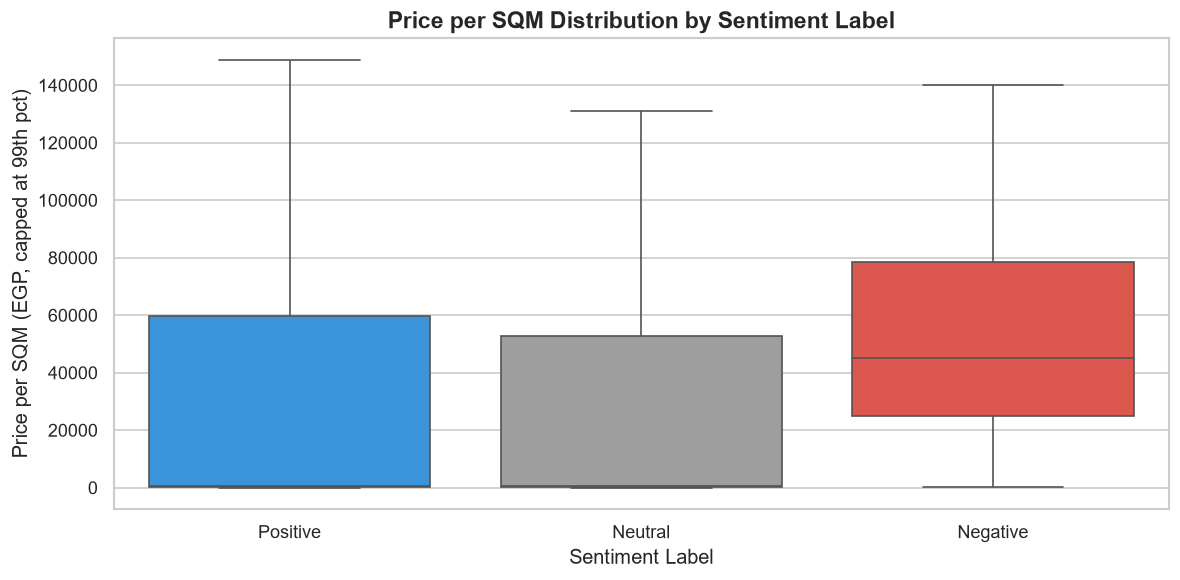

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

order = ["Positive", "Neutral", "Negative"]
palette = {"Positive": "#2196F3", "Neutral": "#9E9E9E", "Negative": "#F44336"}

plot_data = df_en_valid.dropna(subset=["price_per_sqm", "sentiment_label"]).copy()
# Cap outliers at 99th percentile for readability
cap = plot_data["price_per_sqm"].quantile(0.99)
plot_data["price_per_sqm_capped"] = plot_data["price_per_sqm"].clip(upper=cap)

sns.boxplot(
    data=plot_data,
    x="sentiment_label",
    y="price_per_sqm_capped",
    order=order,
    palette=palette,
    ax=ax,
    showfliers=False
)
ax.set_title("Price per SQM Distribution by Sentiment Label", fontsize=14, fontweight="bold")
ax.set_xlabel("Sentiment Label")
ax.set_ylabel("Price per SQM (EGP, capped at 99th pct)")
plt.tight_layout()
plt.savefig(r"F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\nlp_outputs\06_boxplot_price_by_sentiment.png")
plt.show()

## 7. Merge NLP Columns Back to Full Dataset

NLP was only applied to English listings. For non-English rows, we fill:
- `topic_label` → `"Non-English"`
- `sentiment_score` → `0.0` (neutral)
- `sentiment_label` → `"Neutral"`
- `lang` → detected language code

In [24]:
# Select only NLP-enriched columns from EN valid rows
nlp_cols = df_en_valid[["listing_id", "lang", "topic_id", "topic_label",
                         "topic_confidence", "sentiment_score", "sentiment_label",
                         "description_clean"]].copy()

# Merge onto full dataframe
df_nlp = df.merge(nlp_cols, on="listing_id", how="left")

# Fill defaults for non-English rows
df_nlp["lang"] = df_nlp["lang_x"].combine_first(df_nlp["lang_y"]) if "lang_x" in df_nlp.columns else df_nlp["lang"]

# If lang columns were duplicated due to merge, fix
for col in ["lang_x", "lang_y"]:
    if col in df_nlp.columns:
        df_nlp.rename(columns={"lang_x": "lang"}, inplace=True) if col == "lang_x" else None
        df_nlp.drop(columns=[c for c in df_nlp.columns if c == "lang_y"], inplace=True)

df_nlp["topic_label"].fillna("Non-English", inplace=True)
df_nlp["sentiment_score"].fillna(0.0, inplace=True)
df_nlp["sentiment_label"].fillna("Neutral", inplace=True)
df_nlp["description_clean"].fillna("", inplace=True)

print(f"Output shape: {df_nlp.shape}")
print("\ntopic_label distribution:")
print(df_nlp["topic_label"].value_counts())
print("\nsentiment_label distribution:")
print(df_nlp["sentiment_label"].value_counts())

Output shape: (35830, 78)

topic_label distribution:
topic_label
Location, Amenities & Accessibility    11751
Real Estate Business & Investment      10721
Property Sales & Luxury Communities     4232
Modern Residential Communities          3888
Furnished Rental Properties             3733
Name: count, dtype: int64

sentiment_label distribution:
sentiment_label
Positive    31248
Neutral      2629
Negative      448
Name: count, dtype: int64


## 8. Export — `egypt_re_nlp.csv`

In [25]:
output_path = r'F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_nlp.csv'
df_nlp.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Rows: {len(df_nlp):,}  |  Columns: {df_nlp.shape[1]}")

# Confirm NLP columns are present
nlp_added = ["lang", "topic_label", "topic_id", "topic_confidence",
              "sentiment_score", "sentiment_label", "description_clean"]
present = [c for c in nlp_added if c in df_nlp.columns]
print(f"\nNLP columns added: {present}")

Saved: F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_nlp.csv
Rows: 35,830  |  Columns: 78

NLP columns added: ['lang', 'topic_label', 'topic_id', 'topic_confidence', 'sentiment_score', 'sentiment_label', 'description_clean']


## 9. Summary

In [27]:
print("=" * 55)
print("NOTEBOOK 04 — NLP ANALYSIS SUMMARY")
print("=" * 55)
print(f"Total listings          : {len(df):,}")
print(f"English descriptions    : {len(df_en):,}")
print(f"Arabic descriptions     : {len(df_ar):,}")
print(f"Other / Unknown         : {len(df) - len(df_en) - len(df_ar):,}")
print(f"EN valid for NLP        : {len(df_en_valid):,}")
print(f"TF-IDF features         : {tfidf_matrix.shape[1]}")
print(f"LDA topics              : {N_TOPICS}")
print(f"Avg sentiment score     : {df_nlp['sentiment_score'].mean():.4f}")
print(f"Output file             : egypt_re_nlp.csv")
print(f"Figures saved to        : ./nlp_outputs/")
print("=" * 55)
print("\nNext step → 05_ml_prediction.ipynb")

NOTEBOOK 04 — NLP ANALYSIS SUMMARY
Total listings          : 35,830
English descriptions    : 34,325
Arabic descriptions     : 1,494
Other / Unknown         : 11
EN valid for NLP        : 34,325
TF-IDF features         : 500
LDA topics              : 5
Avg sentiment score     : 0.7424
Output file             : egypt_re_nlp.csv
Figures saved to        : ./nlp_outputs/

Next step → 05_ml_prediction.ipynb
